In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
ime = "eurusd"

df = pd.read_csv(f"data/{ime}.csv")

print(df.columns)
print(df.head())

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%m/%d/%Y",
    errors="raise"
)

# Sort oldest -> newest
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.tail())

Index(['Date', 'Close'], dtype='str')
       Date   Close
0  1/1/1999  1.1680
1  1/2/1999  1.1680
2  1/3/1999  1.1680
3  1/4/1999  1.1812
4  1/5/1999  1.1755
        Date   Close
0 1999-01-01  1.1680
1 1999-01-02  1.1680
2 1999-01-03  1.1680
3 1999-01-04  1.1812
4 1999-01-05  1.1755
            Date    Close
10075 2026-08-02  1.15437
10076 2026-08-03  1.15066
10077 2026-08-04  1.15318
10078 2026-08-05  1.15562
10079 2026-08-06  1.15235


In [3]:
features = ["Close"]

# Scale data
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

In [4]:
LOOKBACK = 30

X = []
y = []

for i in range(LOOKBACK, len(scaled)):
    X.append(scaled[i - LOOKBACK:i])
    y.append(scaled[i, 0])     # Close value

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10050, 30, 1)
y shape: (10050,)


In [5]:
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

In [6]:
model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, len(features))),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100


c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0101 - mae: 0.0474 - val_loss: 2.0251e-04 - val_mae: 0.0109
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 5.4453e-04 - mae: 0.0180 - val_loss: 2.3931e-04 - val_mae: 0.0121
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.8061e-04 - mae: 0.0169 - val_loss: 1.8156e-04 - val_mae: 0.0104
Epoch 4/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.2508e-04 - mae: 0.0159 - val_loss: 1.8120e-04 - val_mae: 0.0105
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.9345e-04 - mae: 0.0153 - val_loss: 1.5773e-04 - val_mae: 0.0097
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.7847e-04 - mae: 0.0150 - val_loss: 1.3620e-04 - val_mae: 0.0090
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.4925e-04 - mae: 0.0144 - val_loss: 1.2936e-04 - val_mae: 0.0088
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.9906e-04 - mae: 0.0133 - val_loss: 1.3369e-04 - val_mae:

In [7]:
pred = model.predict(X_test)

# Convert predicted Close back to original scale
dummy = np.zeros((len(pred), 2))
dummy[:, 1] = pred[:, 0]

pred_close = scaler.inverse_transform(dummy)[:, 1]

print("Predicted close:")
print(pred_close[:10])


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Predicted close:
[1.20397287 1.19746589 1.20370306 1.20458283 1.20483948 1.20510325
 1.21118237 1.2119677  1.21282875 1.21182951]


In [8]:
pred = model.predict(X_test)

# Convert predicted Close back to original scale
dummy = np.zeros((len(pred), 2))
dummy[:, 1] = pred[:, 0]

pred_close = scaler.inverse_transform(dummy)[:, 1]

# Convert measured Close back to original scale
dummy_y = np.zeros((len(y_test), 2))
dummy_y[:, 1] = y_test

measured_close = scaler.inverse_transform(dummy_y)[:, 1]

# Dates for test period
test_dates = df["Date"].iloc[LOOKBACK + split_idx:].reset_index(drop=True)

min_len = min(len(test_dates), len(measured_close), len(pred_close))

test_dates = test_dates.iloc[:min_len]
measured_close = measured_close[:min_len]
pred_close = pred_close[:min_len]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


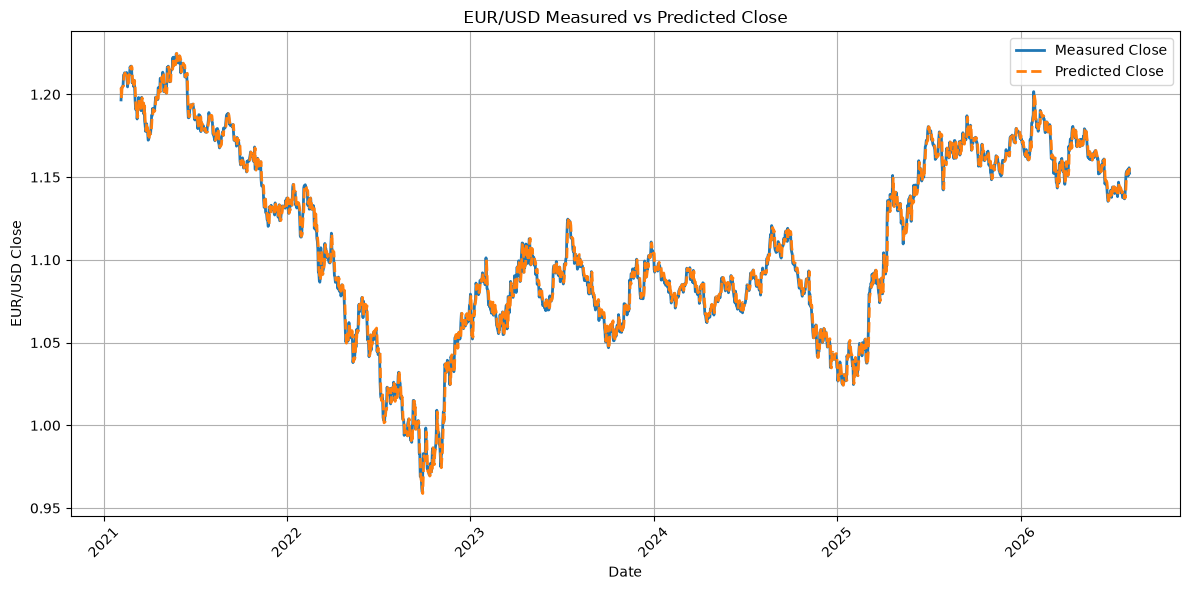

MAE: 0.0031091240485970413
RMSE: 0.0044683038373496235
R^2: 0.9937097708547606


In [9]:
plt.figure(figsize=(12, 6))

plt.plot(test_dates, measured_close, label="Measured Close", linewidth=2)
plt.plot(test_dates, pred_close, label="Predicted Close", linewidth=2, linestyle="--")

plt.title(f"{ime.upper()[0:3]}/{ime.upper()[3:6]} Measured vs Predicted Close")
plt.xlabel("Date")
plt.ylabel(f"{ime.upper()[0:3]}/{ime.upper()[3:6]} Close")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mae = mean_absolute_error(measured_close, pred_close)
rmse = np.sqrt(mean_squared_error(measured_close, pred_close))
r2 = r2_score(measured_close, pred_close)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

In [10]:
savename = f"models/{ime}_{LOOKBACK}"
model.save(f"{savename}_lstm.keras")
joblib.dump(scaler, f"{savename}_scaler.pkl")
config = {
    "lookback": LOOKBACK,
    "features": features
}

joblib.dump(config, f"{savename}_config.pkl")

['models/eurusd_30_config.pkl']

In [11]:
from tensorflow.keras.models import load_model
import joblib

loadname = savename
model = load_model(f"{loadname}_lstm.keras")
scaler = joblib.load(f"{loadname}_scaler.pkl")
config = joblib.load(f"{loadname}_config.pkl")

LOOKBACK = config["lookback"]
features = config["features"]